Выполнение практического задания 3.

Устанавливаем и подключаем библиотеки

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go

Загружаем данные. Так как нет названий колонок, сами их делаем, также скипаем первую строку с NaN

In [76]:
cols = [
    'label',
    'sender_user_id',
    'receiver_user_id',
    'sender_account',
    'receiver_account',
    'amount',
    'transaction_type',
    'status',
    'sender_before',
    'sender_after',
    'receiver_before',
    'receiver_after',
    'unused_12',
    'unused_13',
    'unused_14',
    'unused_15',
    'sender_ts',
    'receiver_ts',
    'sender_account_copy',
    'off_19',
    'off_20',
    'transaction_id',
    'transaction_time',
    'sender_type',
    'receiver_type',
]

df = pd.read_csv('FinFraud_Labelled.csv', sep='|', header=None, names=cols, skiprows=1)

df.head()

,label,sender_user_id,receiver_user_id,sender_account,receiver_account,amount,transaction_type,status,sender_before,sender_after,...,unused_15,sender_ts,receiver_ts,sender_account_copy,off_19,off_20,transaction_id,transaction_time,sender_type,receiver_type
0,N-RegC2C,PN_EU_3_4,PN_EU_0_883,EUAcc3_4,EUAcc0_883,68897.74,Ind,SU,1.000000e+08,9.993041e+07,...,NaN,01/06/2011 00:09:01,01/06/2011 00:09:01,EUAcc3_4,NaN,NaN,C2C201161.099,01/06/2011 00:09:01,EU,EU
1,N-RegC2C,PN_EU_1_139,PN_EU_0_754,EUAcc1_139,EUAcc0_754,68945.47,Ind,SU,1.000000e+08,9.993037e+07,...,NaN,01/06/2011 00:15:23,01/06/2011 00:15:23,EUAcc1_139,NaN,NaN,C2C201161.01515,01/06/2011 00:15:23,EU,EU
2,N-RegDep,PN_Ret2,PN_EU_3_17,RAcc2,EUAcc3_17,9715.41,Dt,SU,1.000000e+09,9.999903e+08,...,NaN,01/06/2011 00:22:07,01/06/2011 00:22:07,RAcc2,NaN,NaN,Dp201161.02222,01/06/2011 00:22:07,RET,EU
3,N-RegDep,PN_Ret1,PN_EU_0_266,RAcc1,EUAcc0_266,79303.74,Dt,SU,1.000000e+09,9.999207e+08,...,NaN,01/06/2011 00:22:35,01/06/2011 00:22:35,RAcc1,NaN,NaN,Dp201161.02222,01/06/2011 00:22:35,RET,EU
4,N_Reg_RC,PN_EU_0_905,operator,EUAcc0_905,A0,929.92,ArRC,SU,1.000000e+08,9.999907e+07,...,NaN,01/06/2011 00:29:56,01/06/2011 00:29:56,EUAcc0_905,NaN,NaN,Rc201161.02929,01/06/2011 00:29:56,EU,operator


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54848 entries, 0 to 54847
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   label                54848 non-null  str    
 1   sender_user_id       54848 non-null  str    
 2   receiver_user_id     54848 non-null  str    
 3   sender_account       54848 non-null  str    
 4   receiver_account     54848 non-null  str    
 5   amount               54848 non-null  float64
 6   transaction_type     54848 non-null  str    
 7   status               54848 non-null  str    
 8   sender_before        54848 non-null  float64
 9   sender_after         54848 non-null  float64
 10  receiver_before      54848 non-null  float64
 11  receiver_after       54848 non-null  float64
 12  unused_12            54848 non-null  bool   
 13  unused_13            54848 non-null  bool   
 14  unused_14            0 non-null      float64
 15  unused_15            0 non-null      float64
 1

Описание полей есть в методических указаниях.

Переделаем поля со временем и датой из str во временной формат.

In [78]:
df['sender_ts'] = pd.to_datetime(df['sender_ts'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df['receiver_ts'] = pd.to_datetime(df['receiver_ts'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54848 entries, 0 to 54847
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   label                54848 non-null  str           
 1   sender_user_id       54848 non-null  str           
 2   receiver_user_id     54848 non-null  str           
 3   sender_account       54848 non-null  str           
 4   receiver_account     54848 non-null  str           
 5   amount               54848 non-null  float64       
 6   transaction_type     54848 non-null  str           
 7   status               54848 non-null  str           
 8   sender_before        54848 non-null  float64       
 9   sender_after         54848 non-null  float64       
 10  receiver_before      54848 non-null  float64       
 11  receiver_after       54848 non-null  float64       
 12  unused_12            54848 non-null  bool          
 13  unused_13            54848 non-null  bool 

Зная, что метки всех мошшенических транзакций начинаются с F.., посмотрим, сколько мошеннических транзакций в датасете и к какому типу они относятся.

In [79]:
fraud_labels = df[df['label'].str.startswith('F')]['label'].value_counts()
print(fraud_labels)

label
F_bot          721
F-Mule-With    717
F_SevWith      240
Name: count, dtype: int64


В методичке указано: в наборе данных присутствуют два типа мошеннических действий: кража мобильного телефона или заражение мобильным ботнетом, но меток с F.. выдало 3.
 
F_bot точно относится к заражению ботнетом. Скорее всего, F-Mule-With тоже относится к заражению ботнетом, потому что mule - с финанcового ?сленга? счет-посредник для отмывания денег: условно, bot отправляет Mule деньги, которые Mule потом переправляет куда-то еще. ТОгда F_SevWith - кража телефона. Может, sev это several(несколько): когда телефон крадут, то все деньги раскидывают в несколько раз.

Теперь добавим признак is_fraud и названия схемам мошенничества соответственно предположениям. Отобразим количество всяких транзакций на диаграммах.

Всего транзакций: 54848
Из них мошеннических: 1678 (3.06%)

fraud_type
Обычные транзакции         53170
Ботнет                       721
Ботнет (счет-посредник)      717
Кража телефона               240


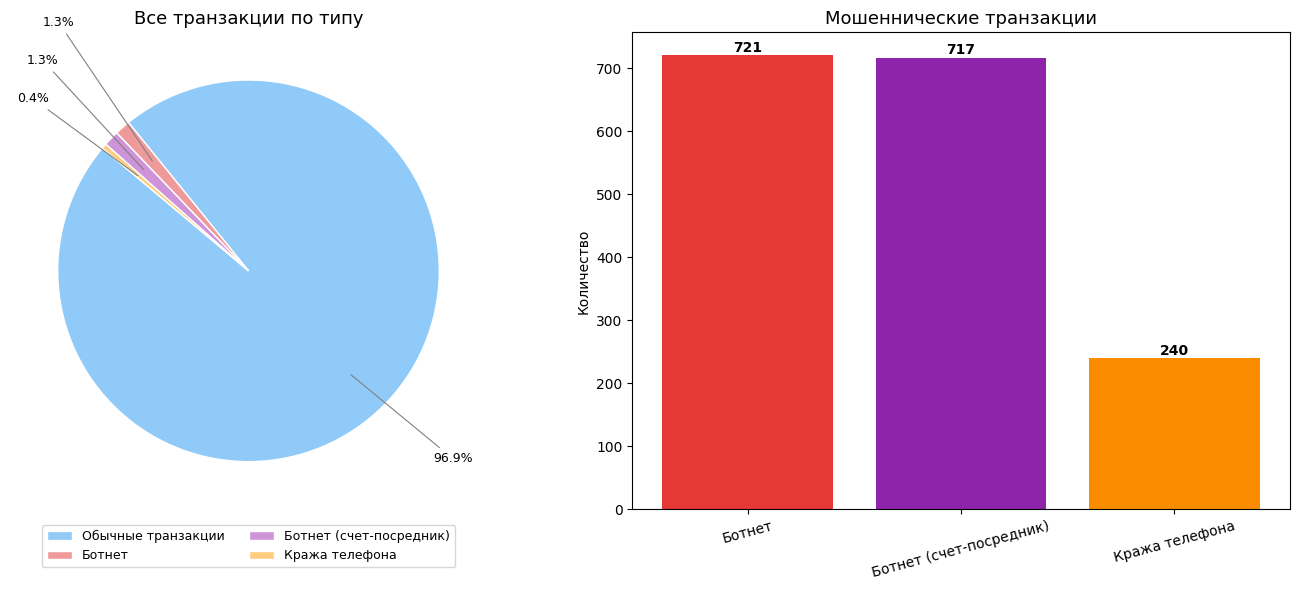

In [80]:
df['is_fraud'] = df['label'].str.startswith('F').fillna(False)

def get_fraud_type(label):
    if label == 'F_bot':
        return 'Ботнет'
    elif label == 'F-Mule-With':
        return 'Ботнет (счет-посредник)'
    elif label == 'F_SevWith':
        return 'Кража телефона'
    else:
        return 'Обычные транзакции'

df['fraud_type'] = df['label'].apply(get_fraud_type)

fraud_total = df['is_fraud'].sum()
print(f"Всего транзакций: {len(df)}")
print(f"Из них мошеннических: {fraud_total} ({fraud_total / len(df) * 100:.2f}%)")
print()
print(df['fraud_type'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = df['fraud_type'].value_counts()
colors_pie = ['#90CAF9', '#EF9A9A', '#CE93D8', '#FFCC80']

wedges, _ = axes[0].pie(
    counts.values,
    labels=None,
    autopct=None,
    colors=colors_pie,
    startangle=140,
    wedgeprops=dict(linewidth=1, edgecolor='white')
)

total = sum(counts.values)
label_data = []
for wedge, val in zip(wedges, counts.values):
    mid_angle = (wedge.theta2 + wedge.theta1) / 2
    rad = np.radians(mid_angle)
    cx, cy = np.cos(rad), np.sin(rad)
    pct = val / total * 100
    label_data.append({
        'x1': 0.75 * cx, 'y1': 0.75 * cy,
        'x2': 1.38 * cx, 'y2': 1.38 * cy,
        'ha': 'left' if cx > 0 else 'right',
        'pct': pct
    })

label_data.sort(key=lambda d: d['y2'])
min_sep = 0.20
for i in range(1, len(label_data)):
    same_side = abs(label_data[i]['x2'] - label_data[i-1]['x2']) < 0.6
    too_close  = label_data[i]['y2'] - label_data[i-1]['y2'] < min_sep
    if same_side and too_close:
        label_data[i]['y2'] = label_data[i-1]['y2'] + min_sep

for d in label_data:
    axes[0].annotate(
        f"{d['pct']:.1f}%",
        xy=(d['x1'], d['y1']), xytext=(d['x2'], d['y2']),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
        ha=d['ha'], va='center', fontsize=9
    )

axes[0].legend(
    wedges, counts.index,
    loc='upper center', bbox_to_anchor=(0.5, -0.02),
    ncol=2, fontsize=9, frameon=True
)
axes[0].set_title('Все транзакции по типу', fontsize=13)

fraud_counts = df[df['is_fraud']]['fraud_type'].value_counts()
axes[1].bar(fraud_counts.index, fraud_counts.values, color=['#E53935', '#8E24AA', '#FB8C00'])
axes[1].set_title('Мошеннические транзакции', fontsize=13)
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(fraud_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Мошеннических транзакций всего около 3% от общего числа: ожидаемо мало, как и бывает в реальных финансовых данных. Распределение визуально может подтверждать гипотезу, что F_bot и F-Mule-With - части схемы ботнета (bot отправляет Mule деньги, которые Mule потом переправляет куда-то еще), потому что они примерно одного размера (~720 каждый). F_SevWith заметно меньше.

Рассмотрим типы отправителей и получателей и типы транзакций

In [81]:
fraud_df = df[df['is_fraud']].copy()

print("Уникальные типы отправителей и получателей:")
print(f"sender_type:   {sorted(df['sender_type'].dropna().unique())}")
print(f"receiver_type: {sorted(df['receiver_type'].dropna().unique())}")
print()
print("Типы отправителей и получателей в мошеннических транзакциях:")
print(fraud_df['sender_type'].value_counts().to_string())
print(fraud_df['receiver_type'].value_counts().to_string())
print()
print("Типы транзакций в мошеннических действиях (схема и тип транзакции):")
print(fraud_df.groupby(['label', 'transaction_type']).size().rename('кол-во').to_string())

Уникальные типы отправителей и получателей:
sender_type:   ['EU', 'RET']
receiver_type: ['EU', 'MER', 'RET', 'operator']

Типы отправителей и получателей в мошеннических транзакциях:
sender_type
EU    1678
receiver_type
RET    957
EU     721

Типы транзакций в мошеннических действиях (схема и тип транзакции):
label        transaction_type
F-Mule-With  Wl                  717
F_SevWith    Wl                  240
F_bot        Ind                 721


В датасете получается только два типа отправителей: EU (конечный пользователь) и RET (агент оператора мобильной связи), а получателей четыре: EU, RET, MER (поставщик услуг и сервисов) и operator (оператор мобильой сети). Это логично, потмоу что отправка денег всегда инициируется либо конечным пользователем, либо агентом, а вот получателем может оказаться кто угодно: в том числе поставщик услуг при обычных покупках или оператор при технических транзакциях. В мошеннических же транзакциях отправители - EU, а получатели EU и RET.

Типы транзакций четко делятся по схемам: F_bot это Ind (перевод между пользователями), а F-Mule-With и F_SevWith это Wl (снятие через агента). Это само по себе уже намекает на схему работы ботнета (и подтверждает гипотезу выше), что сначала деньги bot кидает пользователю (счету-посреднику), а потом этим пользователем деньги выводятся через RET. При краже же деньги просто выводятся через RET.

Зная это все, построим граф мошеннических транзакций, где узлы - идентификароры пользователей, ребра - связи, показывающие перевод денег, вес ребра - количество таких транзакций, размер узла пропроционален входящей степени.

In [82]:
G = nx.DiGraph()
for _, row in fraud_df.iterrows():
    u = row['sender_user_id']
    v = row['receiver_user_id']
    if G.has_edge(u, v):
        G[u][v]['weight']       += 1
        G[u][v]['total_amount'] += row['amount']
    else:
        G.add_edge(u, v, weight=1, total_amount=row['amount'],
                   label=row['label'], tx_type=row['transaction_type'])

node_type_map = {}
for _, row in fraud_df.iterrows():
    node_type_map[row['sender_user_id']]   = row['sender_type']
    node_type_map[row['receiver_user_id']] = row['receiver_type']
nx.set_node_attributes(G, node_type_map, 'node_type')

in_deg = {n: int(G.in_degree(n, weight='weight')) for n in G.nodes()}

print(f"Граф мошеннических транзакций:")
print(f"Уникальных узлов: {G.number_of_nodes()}")
print(f"Уникальных пар (ребер): {G.number_of_edges()}")
print(f"Всего транзакций (сумма весов): {sum(in_deg.values())}")
print()

top_in = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:10]
print("Топ-10 узлов по числу принятых транзакций (взвешенная степень):")
for node, deg in top_in:
    print(f"{node:25s} (тип: {node_type_map.get(node,'?'):}): {deg}")


Граф мошеннических транзакций:
Уникальных узлов: 108
Уникальных пар (ребер): 384
Всего транзакций (сумма весов): 1678

Топ-10 узлов по числу принятых транзакций (взвешенная степень):
PN_EU_0_955               (тип: EU): 199
PN_Ret4                   (тип: RET): 186
PN_EU_1_328               (тип: EU): 183
PN_EU_0_1045              (тип: EU): 172
PN_Ret6                   (тип: RET): 169
PN_EU_0_260               (тип: EU): 167
PN_Ret1                   (тип: RET): 160
PN_Ret5                   (тип: RET): 155
PN_Ret2                   (тип: RET): 145
PN_Ret3                   (тип: RET): 142


In [83]:
hub_set = {n for n, _ in top_in[:4]}

pos = nx.spring_layout(G, seed=42, k=1.8)

edge_x, edge_y = [], []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, mode='lines',
    line=dict(width=0.4, color='#BDBDBD'), hoverinfo='none'
)

type_colors = {'EU': '#1565C0', 'RET': '#2E7D32'}

node_x      = [pos[n][0] for n in G.nodes()]
node_y      = [pos[n][1] for n in G.nodes()]
node_colors = [type_colors.get(node_type_map.get(n, ''), '#9E9E9E') for n in G.nodes()]
node_sizes  = [10 + in_deg.get(n, 0) * 0.8 for n in G.nodes()]
node_text   = [
    f"{n}<br>Тип: {node_type_map.get(n,'?')}<br>Входящих: {in_deg.get(n, 0)}"
    for n in G.nodes()
]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode='markers',
    hoverinfo='text', text=node_text,
    marker=dict(size=node_sizes, color=node_colors,
                line=dict(width=0.5, color='white'))
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title='Граф всех мошеннических транзакций<br>'
              '<sub>Синий: EU-пользователь, зеленый: RET-агент.</sub>',
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        hovermode='closest',
        width=900, height=600
    )
)

for node in hub_set:
    x, y = pos[node]
    fig.add_annotation(x=x, y=y, text=node, showarrow=True,
                       arrowhead=2, ax=35, ay=-30,
                       font=dict(size=9, color='#D32F2F'),
                       bgcolor='rgba(255,255,255,0.85)', borderpad=3)

fig.show()

Сразу видна аномалия: четыре EU-узла (PN_EU_0_955, PN_EU_1_328, PN_EU_0_1045, PN_EU_0_260) получают от 167 до 199 входящих транзакций каждый, а это несравнимо больше любого обычного пользователя (у них по 0). Именно эти четыре EU являются счетами-посредниками в схеме ботнета. На графе они заметно крупнее остальных, и к ним тянутся все ребра.

Теперь рассмотрим часть схемы ботнета с транзакциями типа Ind, где F_bot это зараженные устройства: бот автоматически переводит небольшие суммы на счета-посредники.

In [84]:
bot_df = df[df['label'] == 'F_bot']

G_bot = nx.DiGraph()
for _, row in bot_df.iterrows():
    u = row['sender_user_id']
    v = row['receiver_user_id']
    if G_bot.has_edge(u, v):
        G_bot[u][v]['weight'] += 1
    else:
        G_bot.add_edge(u, v, weight=1, amount=row['amount'])

hub_nodes_bot  = set(bot_df['receiver_user_id'].unique())
infected_nodes = set(bot_df['sender_user_id'].unique())

in_deg_bot_w = {n: int(G_bot.in_degree(n, weight='weight')) for n in G_bot.nodes()}

print(f"Зараженных пользователей (отправляют деньги): {len(infected_nodes)}")
print(f"Счетов-посредников (получают деньги): {len(hub_nodes_bot)}")
print(f"Всего уникальных пар (ребер): {G_bot.number_of_edges()}")
print(f"Всего транзакций (сумма весов): {sum(in_deg_bot_w.values())}")
print()
print("Входящих транзакций на каждый счет-посредник:")
for n in sorted(hub_nodes_bot):
    print(f"{n}: {in_deg_bot_w.get(n, 0)}")

Зараженных пользователей (отправляют деньги): 39
Счетов-посредников (получают деньги): 4
Всего уникальных пар (ребер): 155
Всего транзакций (сумма весов): 721

Входящих транзакций на каждый счет-посредник:
PN_EU_0_1045: 172
PN_EU_0_260: 167
PN_EU_0_955: 199
PN_EU_1_328: 183


In [85]:
pos_bot = {}
hub_list = sorted(hub_nodes_bot)
for i, n in enumerate(hub_list):
    pos_bot[n] = (0.0, (i - (len(hub_list) - 1) / 2) * 1.8)

angles = np.linspace(0, 2 * np.pi, len(infected_nodes), endpoint=False)
for i, n in enumerate(sorted(infected_nodes)):
    pos_bot[n] = (3.5 * np.cos(angles[i]), 3.5 * np.sin(angles[i]))

edge_x, edge_y = [], []
for u, v in G_bot.edges():
    x0, y0 = pos_bot[u]
    x1, y1 = pos_bot[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace_bot = go.Scatter(
    x=edge_x, y=edge_y, mode='lines',
    line=dict(width=0.5, color='rgba(239,154,154,0.5)'), hoverinfo='none'
)

node_trace_bot = go.Scatter(
    x=[pos_bot[n][0] for n in G_bot.nodes()],
    y=[pos_bot[n][1] for n in G_bot.nodes()],
    mode='markers',
    hoverinfo='text',
    text=[
        f"{n}<br>Входящих транзакций: {in_deg_bot_w.get(n, 0)}"
        if n in hub_nodes_bot
        else f"{n}<br>Исходящих транзакций: {G_bot.out_degree(n, weight='weight')}"
        for n in G_bot.nodes()
    ],
    marker=dict(
        size=[28 if n in hub_nodes_bot else 7 for n in G_bot.nodes()],
        color=['#D32F2F' if n in hub_nodes_bot else '#1976D2' for n in G_bot.nodes()],
        line=dict(width=1, color='white')
    )
)

fig = go.Figure(
    data=[edge_trace_bot, node_trace_bot],
    layout=go.Layout(
        title='Часть схемы ботнета с транзакциями типа Ind<br>'
              '<sub>Синий: зараженный EU-пользователь, красный: счет-посредник.',
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=900, height=600
    )
)

for node in hub_nodes_bot:
    x, y = pos_bot[node]
    fig.add_annotation(x=x + 0.15, y=y, text=node, showarrow=False,
                       font=dict(size=10, color='#D32F2F'), xanchor='left')

fig.show()

Все 39 зараженных пользователей ребрами тянутся к 4 центральным узлам (счетам-посредникам). Каждый счет-посредник собирает 167-199 переводов. Это невозможно для обычного пользователя системы.

Теперь рассмотрим вторую часть схемы ботнета с транзакциями типа Wl: те же 4 счета-посредника выводят накопленные средства через RET.

In [86]:
mule_df = df[df['label'] == 'F-Mule-With']

mule_ids = set(bot_df['receiver_user_id'])
ret_ids  = set(mule_df['receiver_user_id'])

print(f"Счетов-посредников (отправляют): {len(mule_ids)}")
print(f"RET-агентов (получают): {len(ret_ids)}")
print(f"Всего транзакций F-Mule-With: {len(mule_df)}")

G_mule = nx.DiGraph()
for _, row in mule_df.iterrows():
    u = row['sender_user_id']
    v = row['receiver_user_id']
    if G_mule.has_edge(u, v):
        G_mule[u][v]['weight'] += 1
    else:
        G_mule.add_edge(u, v, weight=1, amount=row['amount'])

in_deg_mule = {n: int(G_mule.in_degree(n, weight='weight')) for n in G_mule.nodes()}
out_deg_mule = {n: int(G_mule.out_degree(n, weight='weight')) for n in G_mule.nodes()}

print()
print("Исходящих транзакций с каждого счета-посредника:")
for n in sorted(mule_ids):
    print(f"{n}: {out_deg_mule.get(n, 0)}")


Счетов-посредников (отправляют): 4
RET-агентов (получают): 6
Всего транзакций F-Mule-With: 717

Исходящих транзакций с каждого счета-посредника:
PN_EU_0_1045: 170
PN_EU_0_260: 167
PN_EU_0_955: 197
PN_EU_1_328: 183


In [87]:
pos_mule = {}
mule_list = sorted(mule_ids)
ret_list  = sorted(ret_ids)
for i, n in enumerate(mule_list):
    pos_mule[n] = (0, i - (len(mule_list) - 1) / 2)
for i, n in enumerate(ret_list):
    pos_mule[n] = (4, i - (len(ret_list) - 1) / 2)

edge_x_m, edge_y_m = [], []
for u, v in G_mule.edges():
    x0, y0 = pos_mule[u]
    x1, y1 = pos_mule[v]
    edge_x_m += [x0, x1, None]
    edge_y_m += [y0, y1, None]

edge_trace_mule = go.Scatter(
    x=edge_x_m, y=edge_y_m, mode='lines',
    line=dict(width=1.2, color='rgba(149,117,205,0.6)'), hoverinfo='none'
)

node_trace_mule = go.Scatter(
    x=[pos_mule[n][0] for n in G_mule.nodes()],
    y=[pos_mule[n][1] for n in G_mule.nodes()],
    mode='markers+text',
    text=[n for n in G_mule.nodes()],
    textposition=['middle left' if n in mule_ids else 'middle right' for n in G_mule.nodes()],
    textfont=dict(size=9),
    hoverinfo='text',
    hovertext=[
        f"{n}<br>Исходящих транзакций: {out_deg_mule.get(n, 0)}" if n in mule_ids
        else f"RET-агент: {n}<br>Входящих транзакций: {in_deg_mule.get(n, 0)}"
        for n in G_mule.nodes()
    ],
    marker=dict(
        size=[22 if n in mule_ids else 18 for n in G_mule.nodes()],
        color=['#D32F2F' if n in mule_ids else '#2E7D32' for n in G_mule.nodes()],
        line=dict(width=1, color='white')
    )
)

fig = go.Figure(
    data=[edge_trace_mule, node_trace_mule],
    layout=go.Layout(
        title='Часть схемы ботнета с транзакциями типа Wl<br>'
              '<sub>Красные: счета-посредники (EU), зеленые: RET-агенты</sub>',
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=750, height=450
    )
)
fig.show()

4 счета-посредника выводят все деньги по 6 RET-агентам.

Теперь совместим обе стадии схемы ботнета на одном графе, чтобы увидеть всю цепочку движения денег целиком.

In [88]:
infected_ids = set(bot_df['sender_user_id'])

combined_df = pd.concat([bot_df, mule_df])
G_combined = nx.DiGraph()
for _, row in combined_df.iterrows():
    G_combined.add_edge(row['sender_user_id'], row['receiver_user_id'],
                        stage=row['label'], amount=row['amount'])

in_deg_c  = dict(G_combined.in_degree())
out_deg_c = dict(G_combined.out_degree())

pos_combined = {}
inf_list_c  = sorted(infected_ids)
mule_list_c = sorted(mule_ids)
ret_list_c  = sorted(ret_ids)

for i, n in enumerate(inf_list_c):
    pos_combined[n] = (0, i - (len(inf_list_c) - 1) / 2)
for i, n in enumerate(mule_list_c):
    pos_combined[n] = (4, i - (len(mule_list_c) - 1) / 2)
for i, n in enumerate(ret_list_c):
    pos_combined[n] = (8, i - (len(ret_list_c) - 1) / 2)

edge_traces_c = []
for u, v, data in G_combined.edges(data=True):
    color = 'rgba(239,154,154,0.25)' if data['stage'] == 'F_bot' else 'rgba(149,117,205,0.6)'
    x0, y0 = pos_combined[u]
    x1, y1 = pos_combined[v]
    edge_traces_c.append(go.Scatter(
        x=[x0, x1, None], y=[y0, y1, None],
        mode='lines', line=dict(width=1.0, color=color), hoverinfo='none'
    ))

def get_color_c(n):
    if n in mule_ids:    return '#D32F2F'
    elif n in ret_ids:   return '#2E7D32'
    else:                return '#90CAF9'

def get_size_c(n):
    if n in mule_ids:  return 24
    elif n in ret_ids: return 20
    else:              return 7

node_trace_c = go.Scatter(
    x=[pos_combined[n][0] for n in G_combined.nodes()],
    y=[pos_combined[n][1] for n in G_combined.nodes()],
    mode='markers+text',
    text=[n if n not in infected_ids else '' for n in G_combined.nodes()],
    textposition='middle right',
    textfont=dict(size=9),
    hoverinfo='text',
    hovertext=[
        f"{n}<br>Входящих: {in_deg_c.get(n,0)}<br>Исходящих: {out_deg_c.get(n,0)}"
        for n in G_combined.nodes()
    ],
    marker=dict(
        size=[get_size_c(n)  for n in G_combined.nodes()],
        color=[get_color_c(n) for n in G_combined.nodes()],
        line=dict(width=1, color='white')
    )
)

fig = go.Figure(
    data=edge_traces_c + [node_trace_c],
    layout=go.Layout(
        title='Полная схема мошенничества с заражением ботнетом<br>'
              '<sub>Синие: зараженные EU, красные: счета-посредники EU, зеленые: RET-агенты<br>',
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=1050, height=700
    )
)

fig.show()

На графе наглядно показана полная цепочка мошеннической схемы с заражением ботнеомт: деньги покидают пользователей слева направо через 4 узла.

Теперь рассмотрим вторую мошенническую схему - кражу мобильного телефона. Получив доступ к чужому аккаунту через украденный телефон, мошенник быстро выполняет сразу несколько снятий средств (тип транзакций Wl) через разных RET-агентов, чтобы разбить сумму и усложнить ее отслеживание.

In [89]:
sev_df = df[df['label'] == 'F_SevWith']

victim_nodes_sev = set(sev_df['sender_user_id'])
ret_nodes_sev    = set(sev_df['receiver_user_id'])

print(f"Всего жертв (уникальных аккаунтов): {len(victim_nodes_sev)}")
print(f"Задействовано RET-агентов: {len(ret_nodes_sev)}")
print()
withdrawals_per_victim = sev_df.groupby('sender_user_id').size().value_counts()
print("Распределение числа снятий на жертву:")
print(withdrawals_per_victim.to_string())

Всего жертв (уникальных аккаунтов): 60
Задействовано RET-агентов: 6

Распределение числа снятий на жертву:
4    60


In [54]:
top_victims = sev_df['sender_user_id'].value_counts().head(12).index.tolist()
sev_sample  = sev_df[sev_df['sender_user_id'].isin(top_victims)]

withdrawal_count = sev_sample.groupby('sender_user_id').size().to_dict()

G_sev_s = nx.DiGraph()
for _, row in sev_sample.iterrows():
    u, v = row['sender_user_id'], row['receiver_user_id']
    if G_sev_s.has_edge(u, v):
        G_sev_s[u][v]['weight'] += 1
    else:
        G_sev_s.add_edge(u, v, weight=1, amount=row['amount'])

sample_victims = set(sev_sample['sender_user_id'])
sample_ret     = set(sev_sample['receiver_user_id'])

pos_sev = {}
v_list = sorted(sample_victims)
r_list = sorted(sample_ret)
for i, n in enumerate(v_list):
    pos_sev[n] = (0, i - (len(v_list) - 1) / 2)
for i, n in enumerate(r_list):
    pos_sev[n] = (3, i - (len(r_list) - 1) / 2)

edge_x_s, edge_y_s = [], []
for u, v in G_sev_s.edges():
    x0, y0 = pos_sev[u]
    x1, y1 = pos_sev[v]
    edge_x_s += [x0, x1, None]
    edge_y_s += [y0, y1, None]

edge_trace_sev = go.Scatter(
    x=edge_x_s, y=edge_y_s, mode='lines',
    line=dict(width=1.2, color='rgba(255,152,0,0.5)'), hoverinfo='none'
)

node_trace_sev = go.Scatter(
    x=[pos_sev[n][0] for n in G_sev_s.nodes()],
    y=[pos_sev[n][1] for n in G_sev_s.nodes()],
    mode='markers+text',
    text=[n for n in G_sev_s.nodes()],
    textposition=['middle left' if n in sample_victims else 'middle right'
                  for n in G_sev_s.nodes()],
    textfont=dict(size=8),
    hoverinfo='text',
    hovertext=[
        f"{n}<br>Снятий: {withdrawal_count.get(n, 0)}" if n in sample_victims
        else f"RET-агент: {n}"
        for n in G_sev_s.nodes()
    ],
    marker=dict(
        size=[12 if n in sample_victims else 20 for n in G_sev_s.nodes()],
        color=['#E65100' if n in sample_victims else '#1B5E20'
               for n in G_sev_s.nodes()],
        line=dict(width=1, color='white')
    )
)

fig = go.Figure(
    data=[edge_trace_sev, node_trace_sev],
    layout=go.Layout(
        title='Схема кражи телефона со множественными снятиями<br>'
              '<sub>Оранжевые: EU-пользователи-жертвы, зеленые: RET-агенты</sub>',
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=950, height=650
    )
)
fig.show()

По 4 снятия на каждую жертву скорее всего отработанная схема при краже телефона. Причем жертвы не связаны между собой (между ними нет ребер) и обращаются к нескольким RET-агентам.

Интересно, происходят ли эти 4 снятия быстро (как логично было бы поступить мошеннику) или маскируются под обычные транзакции и растягиваются на какое-то время. Для этого проведем анализ.

Временной интервал между первым и последним снятием (минуты)
Кража телефона:
медиана: 10.0 мин   макс: 12.3 мин
Нормальные Wl транзакции:
медиана: 158137.4 мин   макс: 174798.9 мин



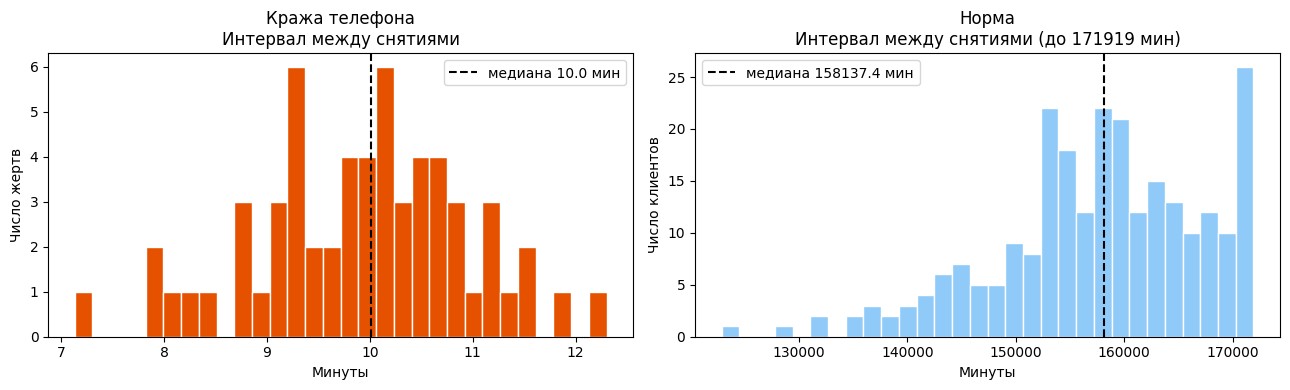

In [90]:
time_spans = (
    sev_df.groupby('sender_user_id')['transaction_time']
    .agg(lambda x: (x.max() - x.min()).total_seconds() / 60)
    .rename('span_min')
)

norm_wl = df[(df['label'] == 'N_RegWith') & (df['transaction_type'] == 'Wl')]
norm_spans = (
    norm_wl.groupby('sender_user_id')['transaction_time']
    .agg(lambda x: (x.max() - x.min()).total_seconds() / 60)
    .rename('span_min')
).dropna()
norm_spans = norm_spans[norm_wl.groupby('sender_user_id').size() >= 4]

print("Временной интервал между первым и последним снятием (минуты)")
print(f"Кража телефона:")
print(f"медиана: {time_spans.median():.1f} мин   макс: {time_spans.max():.1f} мин")
print(f"Нормальные Wl транзакции:")
print(f"медиана: {norm_spans.median():.1f} мин   макс: {norm_spans.max():.1f} мин")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(time_spans, bins=30, color='#E65100', edgecolor='white')
axes[0].axvline(time_spans.median(), color='black', linestyle='--', lw=1.5,
                label=f'медиана {time_spans.median():.1f} мин')
axes[0].set_title('Кража телефона\nИнтервал между снятиями')
axes[0].set_xlabel('Минуты')
axes[0].set_ylabel('Число жертв')
axes[0].legend()

clip_val = norm_spans.quantile(0.95)
axes[1].hist(norm_spans.clip(upper=clip_val), bins=30, color='#90CAF9', edgecolor='white')
axes[1].axvline(norm_spans.median(), color='black', linestyle='--', lw=1.5,
                label=f'медиана {norm_spans.median():.1f} мин')
axes[1].set_title(f'Норма\nИнтервал между снятиями (до {clip_val:.0f} мин)')
axes[1].set_xlabel('Минуты')
axes[1].set_ylabel('Число клиентов')
axes[1].legend()

plt.tight_layout()
plt.show()


Видно, что снятия при краже телефона происходят за считанные минуты, а у обычных пользователей аналогичные операции растянуты на часы и дни. Значит, мошенник действительно действует быстро, чтобы не позволить жертва заблокировать счет.

Теперь проверим, можно ли дополнительно отличить мошеннические транзакции по суммам.

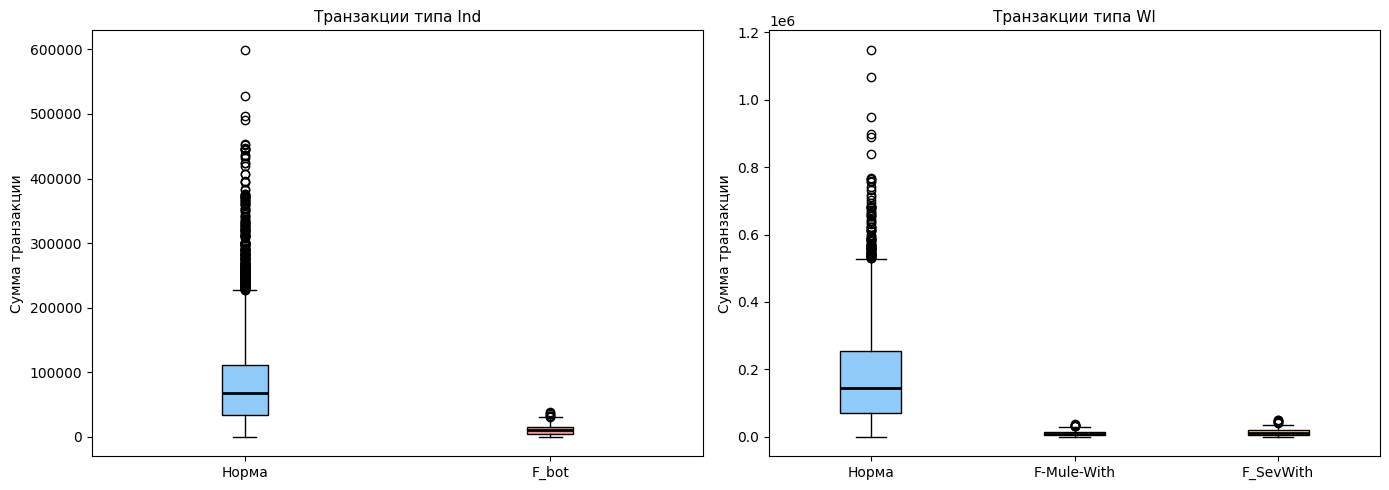

Средние суммы транзакций:
Норма Ind: 82,249
F_bot: 10,690
Норма Wl: 176,306
F-Mule-With: 10,591
F_SevWith: 13,008


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

norm_c2c = df[df['label'] == 'N-RegC2C']['amount']
bot_c2c  = df[df['label'] == 'F_bot']['amount']

bp1 = axes[0].boxplot([norm_c2c, bot_c2c],
                      tick_labels=['Норма', 'F_bot'],
                      patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor('#90CAF9')
bp1['boxes'][1].set_facecolor('#EF9A9A')
axes[0].set_title('Транзакции типа Ind', fontsize=11)
axes[0].set_ylabel('Сумма транзакции')

norm_wl = df[df['label'] == 'N_RegWith']['amount']
mule_wl = df[df['label'] == 'F-Mule-With']['amount']
sev_wl  = df[df['label'] == 'F_SevWith']['amount']

bp2 = axes[1].boxplot([norm_wl, mule_wl, sev_wl],
                      tick_labels=['Норма', 'F-Mule-With', 'F_SevWith'],
                      patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor('#90CAF9')
bp2['boxes'][1].set_facecolor('#EF9A9A')
bp2['boxes'][2].set_facecolor('#FFCC80')
axes[1].set_title('Транзакции типа Wl', fontsize=11)
axes[1].set_ylabel('Сумма транзакции')

plt.tight_layout()
plt.show()

print("Средние суммы транзакций:")
for label, name in [('N-RegC2C', 'Норма Ind'),
                    ('F_bot', 'F_bot'),
                    ('N_RegWith', 'Норма Wl'),
                    ('F-Mule-With', 'F-Mule-With'),
                    ('F_SevWith', 'F_SevWith')]:
    m = df[df['label'] == label]['amount'].mean()
    print(f"{name}: {m:,.0f}")


Разница в суммах получилась показательной. Средняя сумма нормального Ind перевода 82000, тогда как ботнет в среднем 10 700. Видно намеренное дробление сумм, чтобы каждый отдельный перевод не привлек внимания системы мониторинга.

По Wl снятиям картина похожая: нормальные снятия в среднем крупнее, чем мошеннические. При краже телефона мошенник тоже делит сумму на несколько маленьких, чтобы было сложнее отследить.



В ходе анализа датасета с помощью визуализации графов были идентифицированы две мошеннические схемы, соответствующие описанию из методички. Изначальная гипотеза о принадлежности меток к схемам подтвердилась графовым анализом.

Сформулируем признаки мошеннических схем на основе полученных результатов:

Схема 1: Заражение мобильным ботнетом

Мошенники распространяют ботнет, который заражает устройства пользователей. Зараженное устройство автоматически выполняет небольшие транзакции типа Ind на заранее подготовленные счета-посредники. Со счетов-посредников выводят деньги через RET-агентов.

Признаки мошенничества:

- большая концентрация входящих транзакций у единичных узлов. В норме пользователи получают 0-2 входящих перевода, тогда как счета-посредники собирают переводы от большого количетсва источников (в датасете: 4 узла с 167-199 входящими транзакциями каждый);
- те же узлы одновременно являются крупными отправителями. Счет-посредник не просто получает деньги, он их перенаправляет дальше. Такие узлы попадают в топ одновременно по входящим и исходящим транзакциям;
- намеренное дробление сумм. Мошеннические переводы значительно меньше нормальных, чтобы не выделяться в потоке операций (в датасете: суммы транзакций Ind в ~8 раз меньше нормы).


Схема 2: Кража мобильного телефона

Мошенник, украв телефон, получает доступ к мобильному кошельку жертвы и за короткое время выполняет несколько снятий через нескольких RET-агентов. Несколько RET используется, чтобы разбить сумму на 4 снятия и не привлечь внимания.

Признаки мошенничества:

- подозрительно регулярное количество операций на одну жертву. Все снятия происходят серией одинаковой длины, что нехарактерно для обычных пользователей (в датасете: ровно 4 снятия у каждой из 60 жертв);
- высокая скорость серии снятий. Обычные пользователи растягивают несколько операций на часы и дни, а при краже телефона все снятия укладываются в несколько минут (в датасете: медиана у мошеннических транзакций единицы минут против нескольких дней у нормальных);
- жертвы не связаны между собой. Каждый случай кражи независим, жертвы не переводили деньги друг другу;
- намеренное дробление сумм. Суммы отдельных снятий меньше, чем у обычных Wl транзакций.
